In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

os.makedirs("./output", exist_ok=True)

df = pd.read_csv("../datasets/CICEVSE2024/Power Consumption/EVSE-B-PowerCombined.csv")
df["time"] = pd.to_datetime(df["time"])

features = ["shunt_voltage", "bus_voltage_V", "current_mA", "power_mW"]
classes = df["Attack"].unique().tolist()

print(f"Dataset shape: {df.shape}")
print(f"\nAttack class distribution:\n")
print(df["Attack"].value_counts())
print(f"\nUnique attack classes ({df['Attack'].nunique()} total):")
print(df["Attack"].unique())

Dataset shape: (115298, 10)

Attack class distribution:

Attack
vuln-scan        26246
tcp-flood        21367
Backdoor         21137
none             14363
syn-flood        13517
cryptojacking    11596
syn-stealth       7072
Name: count, dtype: int64

Unique attack classes (7 total):
<StringArray>
[    'syn-flood',     'tcp-flood',          'none', 'cryptojacking',
   'syn-stealth',     'vuln-scan',      'Backdoor']
Length: 7, dtype: str


In [23]:
import numpy as np

# Focus on the three relevant classes
classes = df["Attack"].unique().tolist()
df_eda = df.copy()
df_eda["time"] = pd.to_datetime(df_eda["time"])

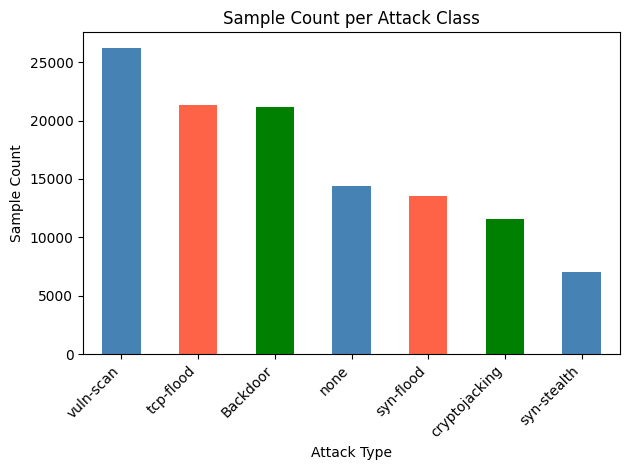

In [28]:
import matplotlib.pyplot as plt

df["Attack"].value_counts().plot(kind="bar", color=["steelblue","tomato","green"])
plt.title("Sample Count per Attack Class")
plt.xlabel("Attack Type")
plt.ylabel("Sample Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("./output/01_class_distribution.png")
plt.show()

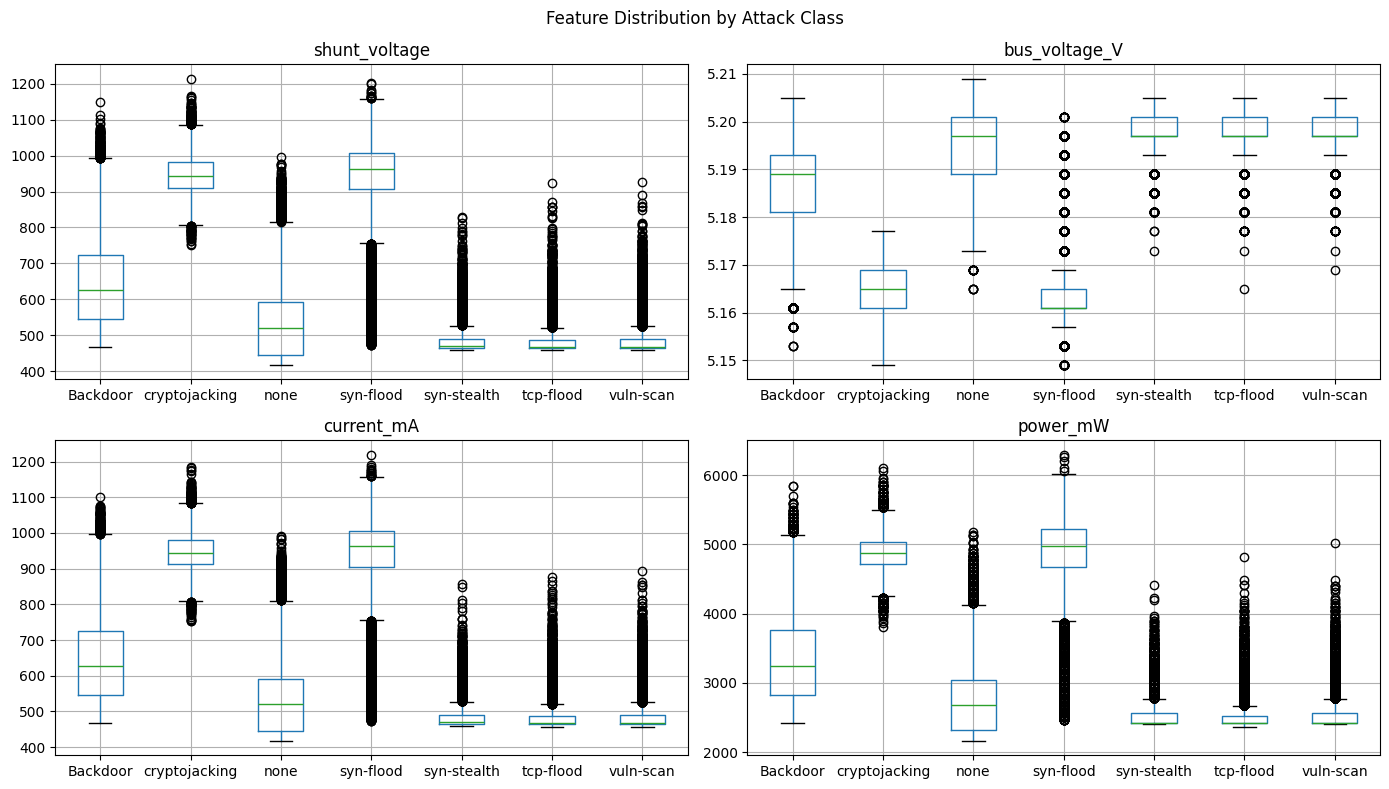

In [30]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

for i, feat in enumerate(features):
    df_eda.boxplot(column=feat, by="Attack", ax=axes[i])
    axes[i].set_title(feat)
    axes[i].set_xlabel("")

plt.suptitle("Feature Distribution by Attack Class")
plt.tight_layout()
plt.savefig("./output/01_class_distribution.png")
plt.show()

Mean deviation from benign baseline:

               shunt_voltage  bus_voltage_V  current_mA   power_mW
Attack                                                            
Backdoor            103.3937        -0.0083    105.4382   535.4605
cryptojacking       406.7545        -0.0303    408.1538  2086.6767
none                  0.0000         0.0000      0.0000     0.0000
syn-flood           387.8952        -0.0304    389.2694  1995.7336
syn-stealth         -51.6980         0.0019    -50.6464  -264.5627
tcp-flood           -54.8081         0.0023    -53.4366  -279.9036
vuln-scan           -52.9674         0.0027    -51.7523  -270.2023


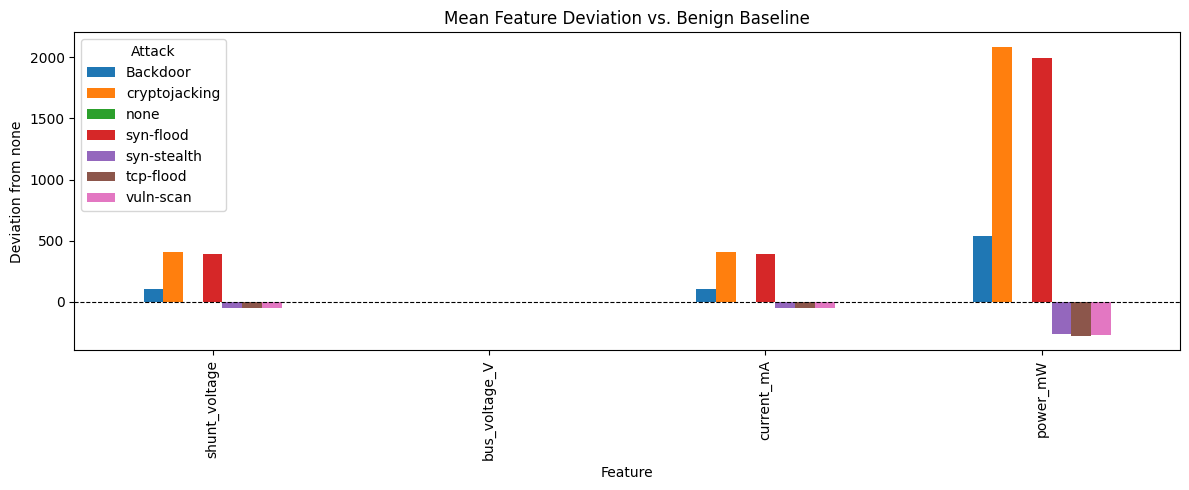

In [31]:
baseline = df_eda[df_eda["Attack"] == "none"][features].mean()

deviation = df_eda.groupby("Attack")[features].mean().subtract(baseline)
print("Mean deviation from benign baseline:\n")
print(deviation.round(4))

deviation.T.plot(kind="bar", figsize=(12, 5))
plt.title("Mean Feature Deviation vs. Benign Baseline")
plt.xlabel("Feature")
plt.ylabel("Deviation from none")
plt.axhline(0, color="black", linewidth=0.8, linestyle="--")
plt.tight_layout()
plt.savefig("./output/04_feature_deviation.png")
plt.show()

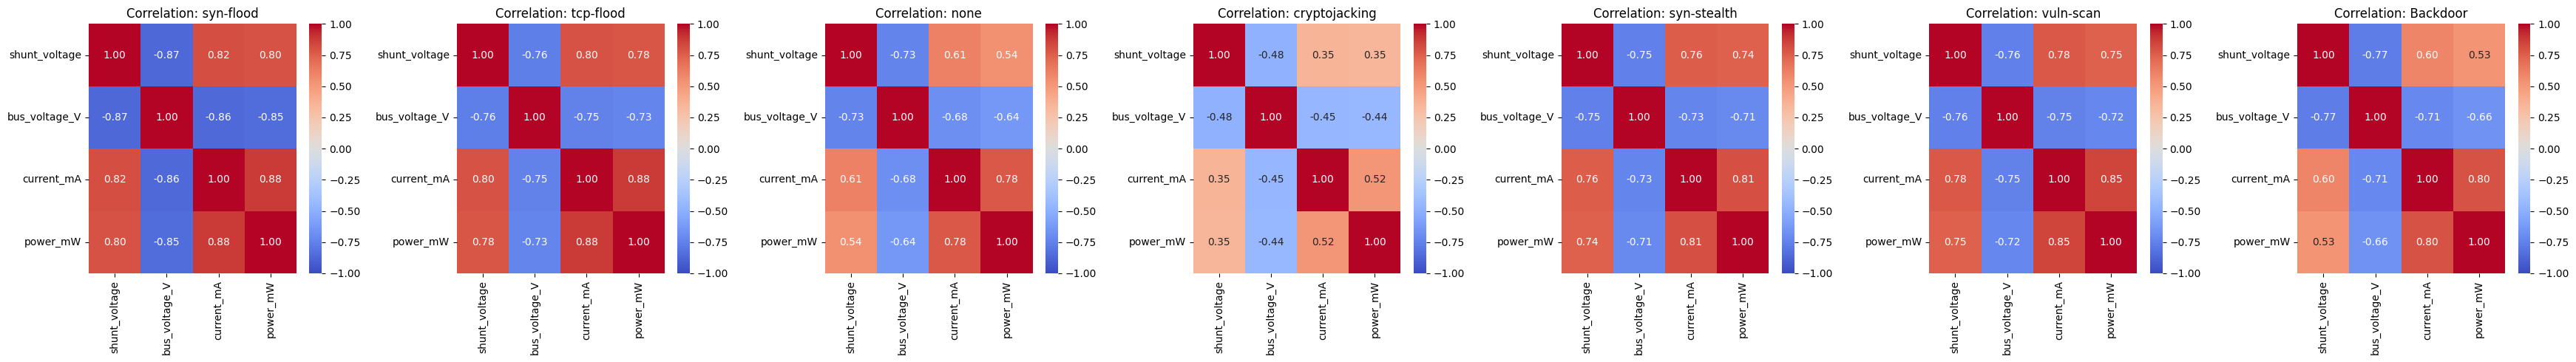

In [33]:
import seaborn as sns

n = len(classes)
fig, axes = plt.subplots(1, n, figsize=(5 * n, 5))

for ax, attack in zip(axes, classes):
    corr = df_eda[df_eda["Attack"] == attack][features].corr()
    sns.heatmap(corr, annot=True, fmt=".2f", ax=ax, cmap="coolwarm", vmin=-1, vmax=1)
    ax.set_title(f"Correlation: {attack}")

plt.tight_layout()
plt.savefig("./output/05_correlation_heatmaps.png")
plt.show()

In [35]:
txt = '''Based on this EDA:
High-signal attacks (cryptojacking, syn-flood, Backdoor) — large enough feature deviation and structural uniqueness to justify training a dedicated generative model
Low-signal attacks (syn-stealth, tcp-flood, vuln-scan) — deviations so small that generative models risk learning noise rather than signal; statistical resampling methods are more honest and safer here
'''
print(txt)

Based on this EDA:
High-signal attacks (cryptojacking, syn-flood, Backdoor) — large enough feature deviation and structural uniqueness to justify training a dedicated generative model
Low-signal attacks (syn-stealth, tcp-flood, vuln-scan) — deviations so small that generative models risk learning noise rather than signal; statistical resampling methods are more honest and safer here

